In [35]:
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Multiply, Dense, Concatenate, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [36]:
# -----------------------
# 1. Load Ratings, Movies, Users
# -----------------------
ratings = pd.read_csv(
    "/content/drive/MyDrive/ml-1m/ratings.dat",
    sep="::",
    engine="python",
    names=["user", "item", "rating", "timestamp"]
)
ratings["label"] = (ratings["rating"] >= 4).astype(int)

movies = pd.read_csv(
    "/content/drive/MyDrive/ml-1m/movies.dat",
    sep="::",
    engine="python",
    names=["item", "title", "genres"],
     encoding="latin-1"
)

users = pd.read_csv(
    "/content/drive/MyDrive/ml-1m/users.dat",
    sep="::",
    engine="python",
    names=["user", "gender", "age", "occupation", "zip"]
)


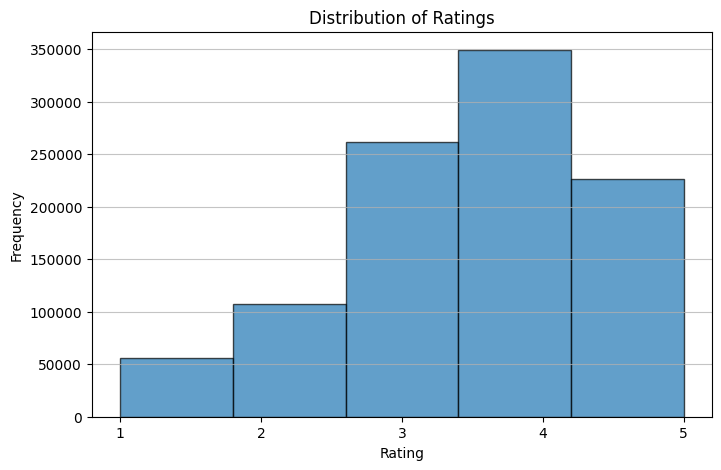

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(ratings['rating'], bins=5, edgecolor='black', alpha=0.7)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', alpha=0.75)
plt.show()

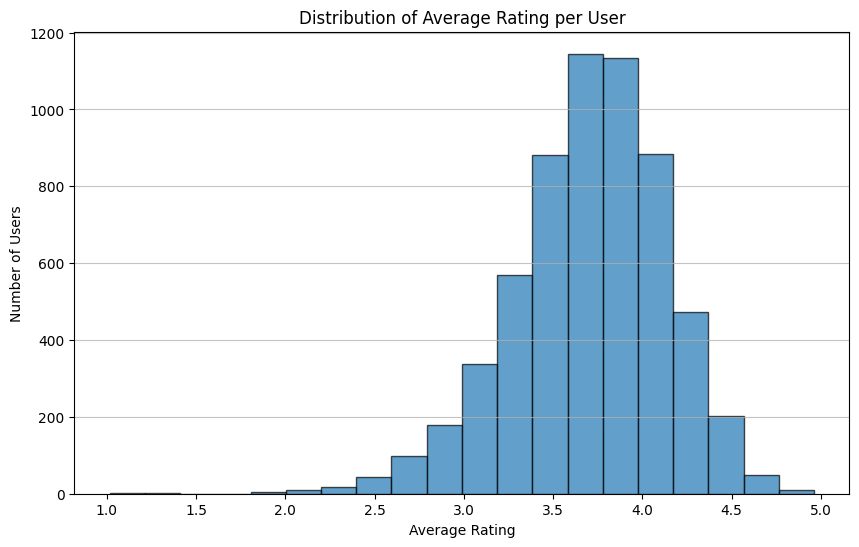

In [38]:
import matplotlib.pyplot as plt

# Calculate the average rating per user
user_avg_ratings = ratings.groupby('user')['rating'].mean()

plt.figure(figsize=(10, 6))
plt.hist(user_avg_ratings, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Average Rating per User')
plt.xlabel('Average Rating')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.show()

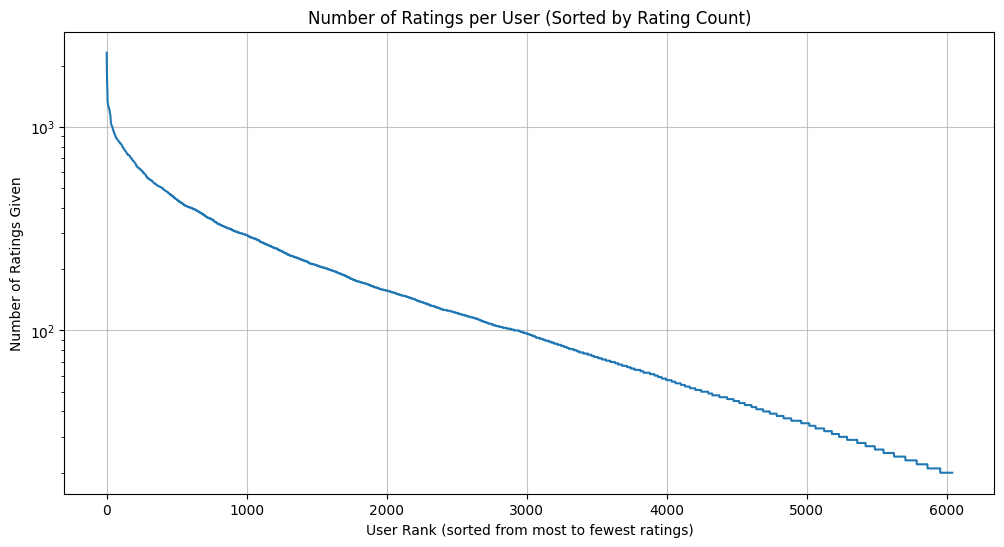

In [39]:
import matplotlib.pyplot as plt

# Calculate the number of ratings per user
user_rating_counts = ratings.groupby('user')['rating'].count()

# Sort the user rating counts to prepare for plotting
sorted_user_rating_counts = user_rating_counts.sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
plt.plot(sorted_user_rating_counts.index, sorted_user_rating_counts.values)
plt.title('Number of Ratings per User (Sorted by Rating Count)')
plt.xlabel('User Rank (sorted from most to fewest ratings)')
plt.ylabel('Number of Ratings Given')
plt.grid(axis='both', alpha=0.75)
plt.yscale('log') # Use log scale for y-axis to better visualize the distribution spread
plt.show()

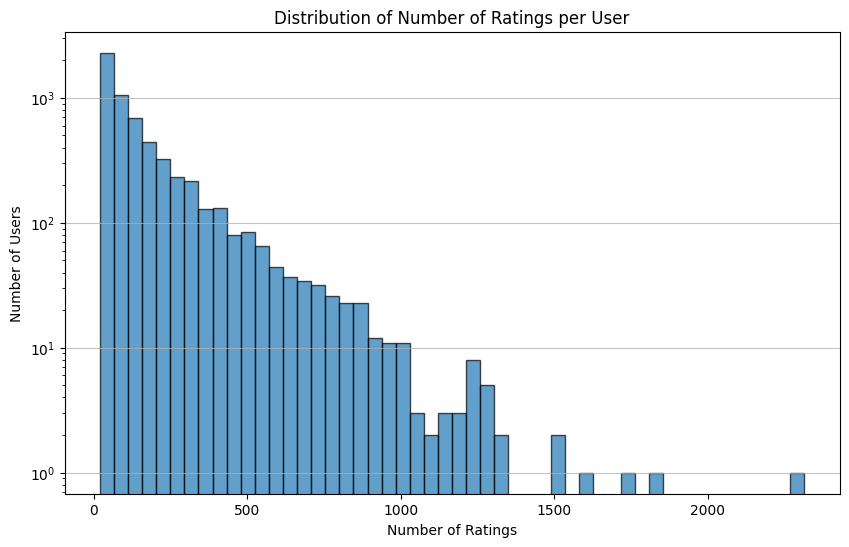

In [40]:
# Calculate the number of ratings per user
user_rating_counts = ratings.groupby('user')['rating'].count()

plt.figure(figsize=(10, 6))
plt.hist(user_rating_counts, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.75)
plt.yscale('log') # Use log scale for y-axis to better visualize the distribution
plt.show()

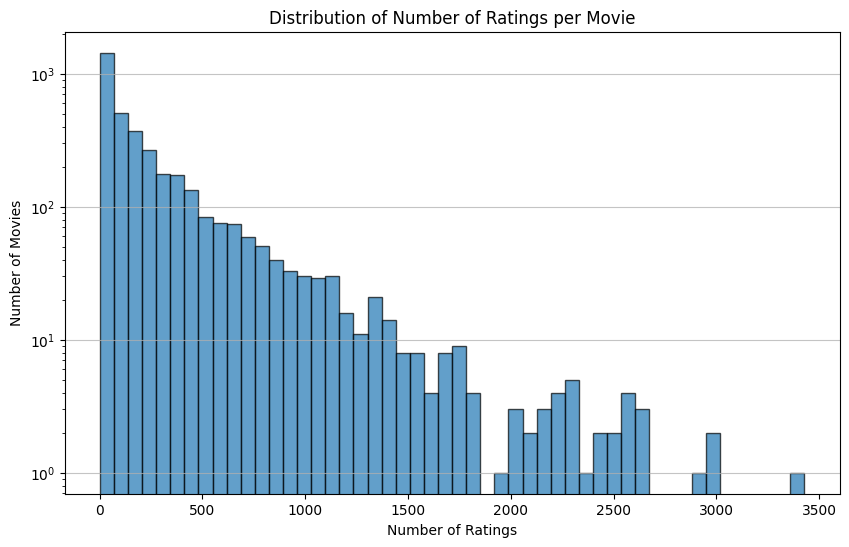

In [41]:
import matplotlib.pyplot as plt

# Calculate the number of ratings per movie
movie_rating_counts = ratings.groupby('item')['rating'].count()

plt.figure(figsize=(10, 6))
plt.hist(movie_rating_counts, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.yscale('log') # Use log scale for y-axis to better visualize the distribution
plt.show()

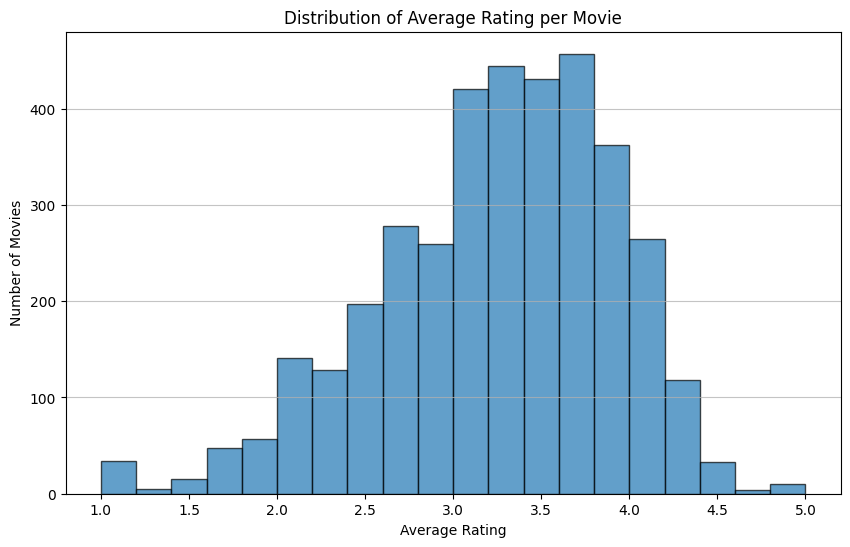

In [42]:
import matplotlib.pyplot as plt

# Calculate the average rating per movie
movie_avg_ratings = ratings.groupby('item')['rating'].mean()

plt.figure(figsize=(10, 6))
plt.hist(movie_avg_ratings, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Average Rating per Movie')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [43]:
import pandas as pd

# Get the top 10 most rated movies
top_10_movies_by_ratings = movie_rating_counts.nlargest(10)

# Merge with the movies DataFrame to get titles and genres
top_10_movies_details = pd.merge(
    top_10_movies_by_ratings.rename('rating_count'),
    movies[['item', 'title', 'genres']],
    left_index=True,
    right_on='item'
)

print("Top 10 Most Rated Movies:")
print(top_10_movies_details.to_markdown(index=False))

Top 10 Most Rated Movies:
|   rating_count |   item | title                                                 | genres                              |
|---------------:|-------:|:------------------------------------------------------|:------------------------------------|
|           3428 |   2858 | American Beauty (1999)                                | Comedy|Drama                        |
|           2991 |    260 | Star Wars: Episode IV - A New Hope (1977)             | Action|Adventure|Fantasy|Sci-Fi     |
|           2990 |   1196 | Star Wars: Episode V - The Empire Strikes Back (1980) | Action|Adventure|Drama|Sci-Fi|War   |
|           2883 |   1210 | Star Wars: Episode VI - Return of the Jedi (1983)     | Action|Adventure|Romance|Sci-Fi|War |
|           2672 |    480 | Jurassic Park (1993)                                  | Action|Adventure|Sci-Fi             |
|           2653 |   2028 | Saving Private Ryan (1998)                            | Action|Drama|War                    

In [44]:
from collections import Counter

# Split genres and count occurrences
genre_counts = Counter()
for genres_str in movies['genres']:
    for genre in genres_str.split('|'):
        genre_counts[genre] += 1

# Convert to DataFrame for easier plotting
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

print("Genre Distribution (Top 10):")
print(genre_df.head(10).to_markdown(index=False))

Genre Distribution (Top 10):
| Genre      |   Count |
|:-----------|--------:|
| Drama      |    1603 |
| Comedy     |    1200 |
| Action     |     503 |
| Thriller   |     492 |
| Romance    |     471 |
| Horror     |     343 |
| Adventure  |     283 |
| Sci-Fi     |     276 |
| Children's |     251 |
| Crime      |     211 |


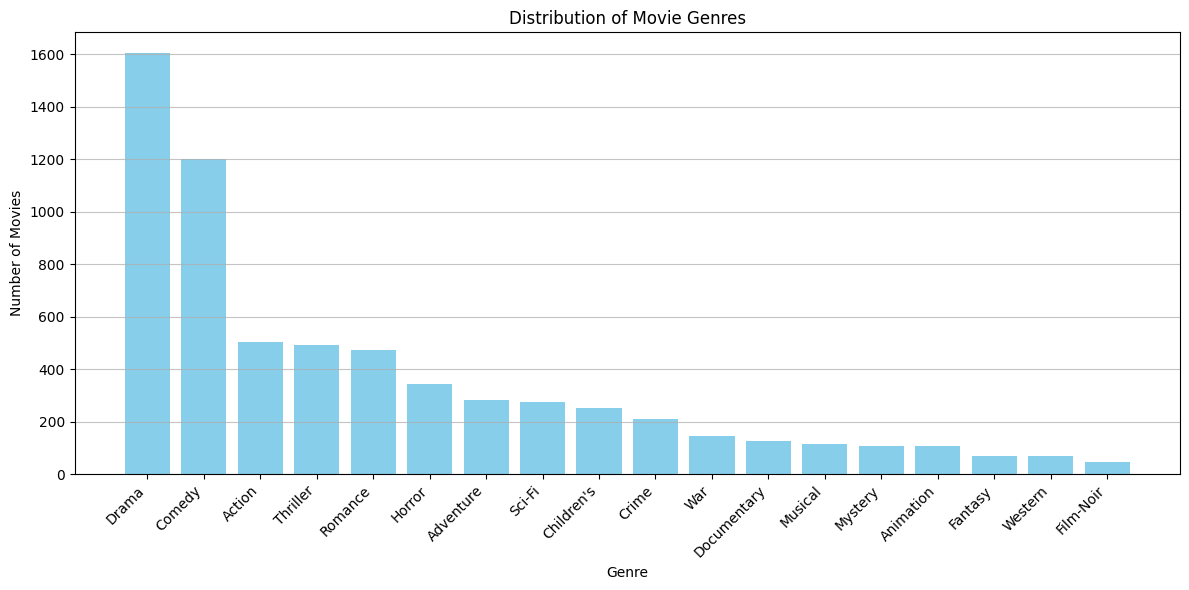

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(genre_df['Genre'], genre_df['Count'], color='skyblue')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.title('Distribution of Movie Genres')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [46]:
import matplotlib.pyplot as plt

# Merge ratings with user gender information
ratings_with_gender = pd.merge(ratings, users[['user', 'gender']], on='user')

# Calculate rating counts for each gender
gender_rating_counts = ratings_with_gender.groupby(['gender', 'rating']).size().unstack(fill_value=0)

print("Rating counts by gender:")
print(gender_rating_counts.to_markdown())

Rating counts by gender:
| gender   |     1 |     2 |      3 |      4 |      5 |
|:---------|------:|------:|-------:|-------:|-------:|
| F        | 13347 | 24548 |  62966 |  87033 |  58546 |
| M        | 42827 | 83009 | 198231 | 261938 | 167764 |


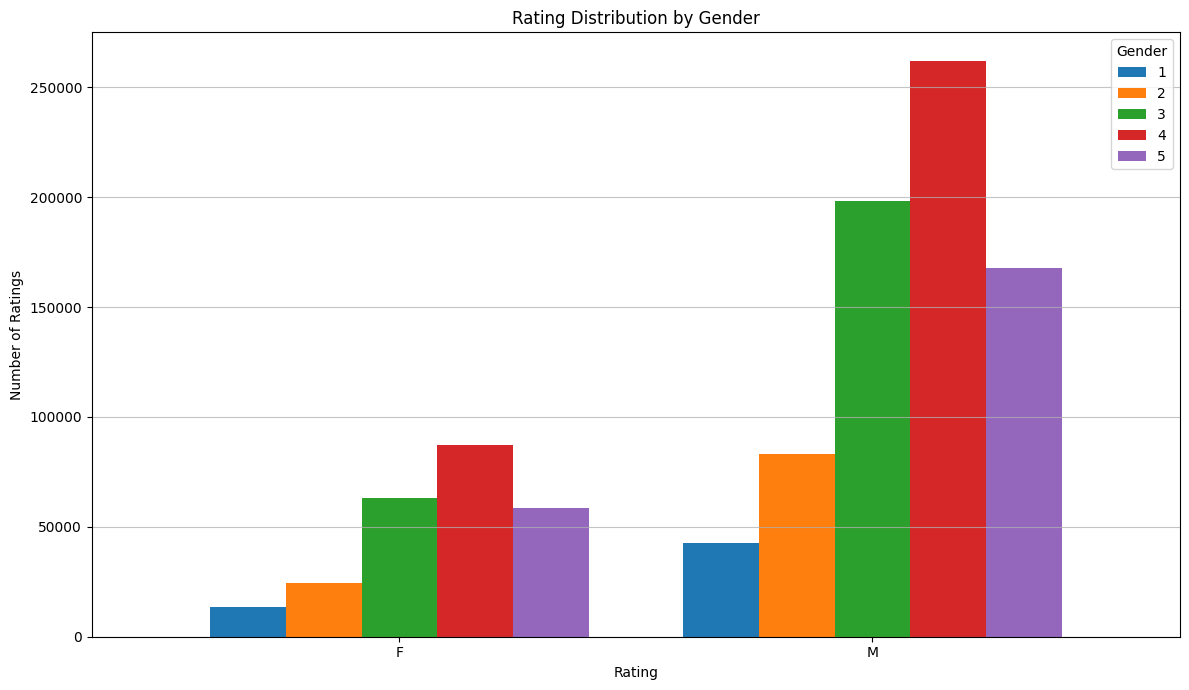

In [47]:
import matplotlib.pyplot as plt

# Plotting the rating distribution by gender
gender_rating_counts.plot(kind='bar', figsize=(12, 7), width=0.8)
plt.title('Rating Distribution by Gender')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Preprocessing


In [48]:
users["gender_enc"] = (users["gender"] == "F").astype(int)
users["age_norm"] = users["age"] / users["age"].max()

In [49]:
# Process genres to multi-hot
all_genres = sorted(set(g for gs in movies["genres"].str.split("|") for g in gs))
genre2idx = {g: i for i, g in enumerate(all_genres)}

def encode_genres(genres_str):
    vec = np.zeros(len(all_genres))
    for g in genres_str.split("|"):
        vec[genre2idx[g]] = 1
    return vec

movies["genre_vec"] = movies["genres"].apply(encode_genres)
item_genre_matrix = movies.set_index("item")["genre_vec"].to_dict()

num_users = ratings.user.max()
num_items = ratings.item.max()
embedding_dim = 64
print("Users:", num_users, "Items:", num_items)

Users: 6040 Items: 3952


In [50]:
# def make_negative_samples(ratings, num_neg=20):
#     user_pos_items = ratings.groupby("user")["item"].apply(set).to_dict()

#     users, items, labels = [], [], []

#     for idx, row in tqdm(ratings.iterrows(), total=len(ratings)):
#         u = row['user']
#         i = row['item']

#         # positive sample
#         users.append(u - 1)
#         items.append(i - 1)
#         labels.append(1)

#         # negative samples
#         for _ in range(num_neg):
#             j = np.random.randint(1, num_items + 1)
#             while j in user_pos_items[u]:
#                 j = np.random.randint(1, num_items + 1)
#             users.append(u - 1)
#             items.append(j - 1)
#             labels.append(0)

#     return np.array(users), np.array(items), np.array(labels)

# train_users, train_items, train_labels = make_negative_samples(ratings)

In [51]:
# -----------------------
# 2. Negative Sampling
# -----------------------
def make_negative_samples(ratings, num_neg=30):
    user_pos_items = ratings.groupby("user")["item"].apply(set).to_dict()
    users, items, labels = [], [], []

    for idx, row in tqdm(ratings.iterrows(), total=len(ratings)):
        u = int(row["user"])
        i = int(row["item"])
        # positive
        users.append(u - 1)
        items.append(i - 1)
        labels.append(1)
        # negatives
        for _ in range(num_neg):
            j = np.random.randint(1, num_items + 1)
            while j in user_pos_items[u]:
                j = np.random.randint(1, num_items + 1)
            users.append(u - 1)
            items.append(j - 1)
            labels.append(0)
    return np.array(users), np.array(items), np.array(labels)



split

In [52]:
train_users, train_items, train_labels = make_negative_samples(ratings, num_neg=30)
u_train, u_val, i_train, i_val, y_train, y_val = train_test_split(
    train_users, train_items, train_labels,
    test_size=0.2, random_state=42
)

100%|██████████| 1000209/1000209 [02:37<00:00, 6350.74it/s]


In [53]:
# item_genre_matrix: dict {movieId -> genre_vector}

max_id = max(item_genre_matrix.keys())
dim = len(next(iter(item_genre_matrix.values())))

# +1 because MovieIDs start at 1
item_genres_arr = np.zeros((max_id + 1, dim), dtype=np.float32)

for movie_id, vec in item_genre_matrix.items():
    item_genres_arr[movie_id] = vec

In [54]:
item_genres_arr.shape

(3953, 18)

In [55]:
train_item_genres = item_genres_arr[i_train]
val_item_genres   = item_genres_arr[i_val]

In [56]:
# Pre-index users
user_df = users.set_index("user")

# Convert to numpy
gender_arr = user_df["gender_enc"].to_numpy()
age_arr    = user_df["age_norm"].to_numpy()

# Fast vectorized lookup
train_user_gender = gender_arr[u_train]
train_user_age    = age_arr[u_train]

val_user_gender = gender_arr[u_val]
val_user_age    = age_arr[u_val]

Model

In [57]:
# -----------------------
# 3. Hybrid NCF + LightGCN + Side Features
# -----------------------
# Inputs
user_gmf_input = Input(shape=(), dtype="int32")
item_gmf_input = Input(shape=(), dtype="int32")
user_mlp_input = Input(shape=(), dtype="int32")
item_mlp_input = Input(shape=(), dtype="int32")
user_gcn_input = Input(shape=(), dtype="int32")
item_gcn_input = Input(shape=(), dtype="int32")

user_gender_input = Input(shape=(), dtype="float32")
user_age_input = Input(shape=(), dtype="float32")
item_genre_input = Input(shape=(len(all_genres),), dtype="float32")

In [58]:
# GMF branch
user_gmf_emb = Embedding(num_users, embedding_dim, embeddings_regularizer=l2(1e-6))(user_gmf_input)
item_gmf_emb = Embedding(num_items, embedding_dim, embeddings_regularizer=l2(1e-6))(item_gmf_input)
gmf_user_vec = Flatten()(user_gmf_emb)
gmf_item_vec = Flatten()(item_gmf_emb)
gmf_output = Multiply()([gmf_user_vec, gmf_item_vec])

In [59]:
# MLP branch
user_mlp_emb = Embedding(num_users, embedding_dim, embeddings_regularizer=l2(1e-6))(user_mlp_input)
item_mlp_emb = Embedding(num_items, embedding_dim, embeddings_regularizer=l2(1e-6))(item_mlp_input)
mlp_user_vec = Flatten()(user_mlp_emb)
mlp_item_vec = Flatten()(item_mlp_emb)
mlp_concat = Concatenate()([mlp_user_vec, mlp_item_vec,
                            user_gender_input[..., None], user_age_input[..., None],
                            item_genre_input])
mlp = Dense(128, activation="relu")(mlp_concat)
mlp = Dropout(0.2)(mlp)
mlp = Dense(64, activation="relu")(mlp)
mlp = Dropout(0.2)(mlp)
mlp = Dense(32, activation="relu")(mlp)

# NeuMF output
neu_output = Concatenate()([gmf_output, mlp])
neu_output = Dense(1, activation="sigmoid")(neu_output)

# LightGCN branch
gcn_user_emb = Embedding(num_users, embedding_dim, embeddings_regularizer=l2(1e-6))(user_gcn_input)
gcn_item_emb = Embedding(num_items, embedding_dim, embeddings_regularizer=l2(1e-6))(item_gcn_input)
gcn_user_vec = Flatten()(gcn_user_emb)
gcn_item_vec = Flatten()(gcn_item_emb)
gcn_output = Multiply()([gcn_user_vec, gcn_item_vec])
gcn_output = Dense(1, activation="sigmoid")(gcn_output)

In [60]:
# Final fusion
final_output = Concatenate()([neu_output, gcn_output])
final_output = Dense(1, activation="sigmoid")(final_output)

model = Model(
    [user_gmf_input, item_gmf_input, user_mlp_input, item_mlp_input,
     user_gcn_input, item_gcn_input,
     user_gender_input, user_age_input, item_genre_input],
    final_output
)

optimizer = keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss="binary_crossentropy")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 64)        │    386,560 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 64)        │    252,928 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 64)        │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 64)        │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1)         │          0 │ input_layer_15[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1)         │          0 │ input_layer_16[0… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_17      │ (None, 18)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 148)       │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ get_item_2[0][0], │
│                     │                   │            │ get_item_3[0][0], │
│                     │                   │            │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     19,072 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 64)        │    386,560 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                 

 Total params: 1,948,037 (7.43 MB)

 Trainable params: 1,948,037 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    [u_train, i_train, u_train, i_train, u_train, i_train,
     train_user_gender, train_user_age, train_item_genres],
    y_train,
    validation_data=([u_val, i_val, u_val, i_val, u_val, i_val,
                      val_user_gender, val_user_age, val_item_genres],
                     y_val),
    batch_size=1024,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)